# IMPORT

In [60]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import random
import math
import time
from memory_profiler import memory_usage

# SEED

In [61]:
# Set a seed value
seed_value = 42
random.seed(seed_value)
np.random.seed(seed_value)
torch.manual_seed(seed_value)

# CUDA

In [62]:
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed_value)
    torch.cuda.manual_seed_all(seed_value)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
print(torch.cuda.is_available())
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)
print()

True
Using device: cuda



# READ TSP FILE

In [63]:
def read_tsp_file(filename):
    with open(filename, 'r') as f:
        lines = f.readlines()
    
    city_coords = []
    for line in lines:
        if line.startswith('EOF'):
            break
        if line[0].isdigit():
            _, x, y = line.strip().split()
            city_coords.append((float(x), float(y)))
    
    n = len(city_coords)
    distance_matrix = [[0] * n for _ in range(n)]
    for i in range(n):
        for j in range(n):
            if i != j:
                distance_matrix[i][j] = int(math.sqrt((city_coords[i][0] - city_coords[j][0])**2 + (city_coords[i][1] - city_coords[j][1])**2))
    
    return distance_matrix, city_coords

# PLOT PATH

In [64]:
def plot_tsp_path(city_coords, path):
    x = [coord[0] for coord in city_coords]
    y = [coord[1] for coord in city_coords]
    
    plt.scatter(x, y, c='blue')
    for i in range(len(path) - 1):
        plt.plot([x[path[i]], x[path[i+1]]], [y[path[i]], y[path[i+1]]], c='red')
    plt.plot([x[path[-1]], x[path[0]]], [y[path[-1]], y[path[0]]], c='red')
    
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.title('TSP Path with Simulated Annealing')
    plt.show()

# TOTAL DISTANCE

In [65]:
def total_distance(path, distance_matrix):
    distance = 0
    for i in range(len(path) - 1):
        distance += distance_matrix[path[i]][path[i+1]]
    distance += distance_matrix[path[-1]][path[0]]
    return distance

# SIMULATED ANNEALING

In [80]:
def simulated_annealing(distance_matrix, initial_temperature, cooling_rate, num_iterations):
    n = len(distance_matrix)
    current_path = list(range(n))
    current_cost = total_distance(current_path, distance_matrix)
    best_path = current_path
    best_cost = current_cost
    temperature = initial_temperature

    for iteration in range(num_iterations):
        i, j = random.sample(range(n), 2)
        new_path = current_path[:]
        new_path[i], new_path[j] = new_path[j], new_path[i]
        new_cost = total_distance(new_path, distance_matrix)

        if new_cost < current_cost or random.random() < math.exp((current_cost - new_cost) / temperature):
            current_path = new_path
            current_cost = new_cost

            if new_cost < best_cost:
                best_path = new_path
                best_cost = new_cost

        temperature *= cooling_rate

    return best_cost, best_path

# DS1

Optimal Cost: 847
Optimal Path: [84, 83, 110, 116, 121, 102, 103, 96, 95, 94, 79, 75, 70, 66, 62, 65, 55, 50, 36, 37, 38, 22, 10, 3, 9, 8, 21, 39, 40, 23, 43, 42, 41, 56, 61, 64, 77, 80, 81, 86, 93, 98, 101, 105, 100, 99, 104, 117, 113, 111, 76, 74, 48, 47, 46, 54, 73, 88, 92, 97, 108, 109, 114, 118, 115, 119, 128, 127, 126, 130, 125, 124, 123, 129, 122, 120, 106, 112, 107, 91, 87, 82, 78, 69, 68, 26, 17, 12, 4, 11, 0, 5, 31, 32, 34, 35, 60, 59, 58, 57, 51, 49, 30, 29, 27, 18, 14, 13, 15, 16, 24, 25, 52, 44, 63, 67, 53, 45, 28, 19, 6, 1, 2, 7, 20, 33, 71, 72, 90, 89, 85]
Execution Time: 17.669944763183594 seconds
Memory Usage: 342.3671875 MiB


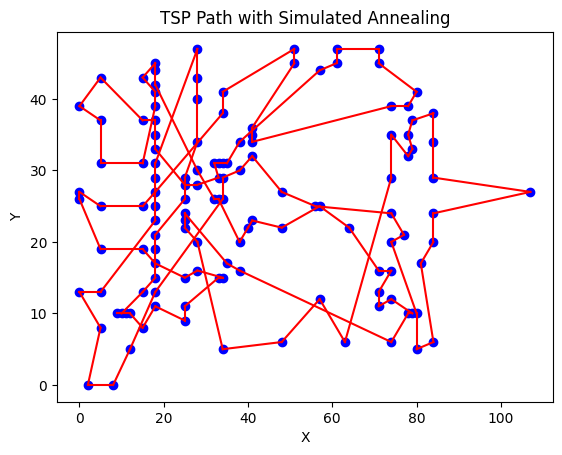

In [52]:
filename = filename = 'C://Users//ARRF//Desktop//rebeka//mid_term_project//data//DS1//DS1.tsp'
distance_matrix, city_coords = read_tsp_file(filename)

start_time = time.time()
cost, path = simulated_annealing(distance_matrix, initial_temperature=100000000, cooling_rate=0.995)
end_time = time.time()

print(f"Optimal Cost: {cost}")
print(f"Optimal Path: {path}")
print(f"Execution Time: {end_time - start_time} seconds")

mem_usage = memory_usage(proc=-1, interval=1, timeout=1)
print(f"Memory Usage: {max(mem_usage)} MiB")

plot_tsp_path(city_coords, path)

# DS2

Optimal Cost: 23445
Optimal Path: [854, 922, 972, 973, 1036, 1170, 1202, 1242, 1287, 1486, 1506, 1516, 1568, 1533, 1558, 1557, 1530, 1398, 1320, 894, 778, 741, 660, 619, 558, 542, 550, 561, 665, 666, 689, 711, 746, 932, 993, 994, 1053, 1054, 1057, 1002, 1004, 1017, 1018, 1019, 976, 966, 967, 968, 1194, 1244, 1316, 1367, 1494, 1493, 1509, 1492, 1424, 1425, 1426, 1427, 1428, 1429, 1401, 1158, 304, 264, 99, 33, 34, 35, 39, 69, 151, 150, 180, 216, 214, 213, 272, 219, 276, 277, 220, 222, 223, 358, 357, 332, 270, 269, 303, 299, 377, 321, 342, 376, 453, 454, 503, 1049, 1048, 1122, 1264, 1376, 1441, 1440, 1439, 1319, 1255, 986, 882, 835, 870, 876, 929, 1022, 1083, 1084, 1142, 1258, 1259, 1260, 1261, 1262, 1263, 1196, 1121, 1088, 1041, 1039, 1038, 1040, 1043, 1089, 1090, 1091, 1055, 1056, 1098, 1150, 1185, 1127, 978, 933, 898, 815, 771, 770, 813, 926, 1118, 1286, 1308, 1394, 1434, 1470, 1471, 1437, 1399, 1388, 1334, 893, 662, 570, 564, 548, 580, 587, 588, 696, 786, 820, 1157, 1226, 1360, 1420, 

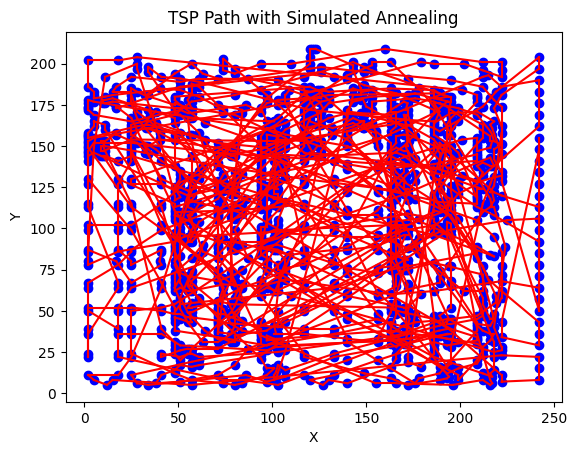

In [81]:
filename = filename = 'C://Users//ARRF//Desktop//rebeka//mid_term_project//data//DS2//DS2.tsp'
distance_matrix, city_coords = read_tsp_file(filename)

start_time = time.time()
cost, path = simulated_annealing(distance_matrix, initial_temperature=100000000, cooling_rate=0.995, num_iterations=10000000)
end_time = time.time()

print(f"Optimal Cost: {cost}")
print(f"Optimal Path: {path}")
print(f"Execution Time: {end_time - start_time} seconds")

mem_usage = memory_usage(proc=-1, interval=1, timeout=1)
print(f"Memory Usage: {max(mem_usage)} MiB")

plot_tsp_path(city_coords, path)

# DS3

Optimal Cost: 50953
Optimal Path: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 

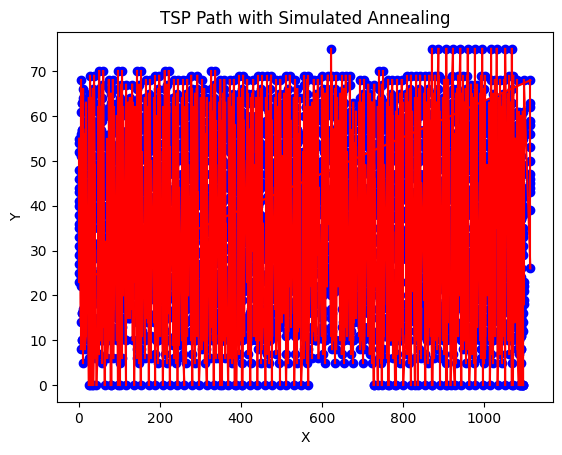

In [82]:
filename = filename = 'C://Users//ARRF//Desktop//rebeka//mid_term_project//data//DS3//DS3.tsp'
distance_matrix, city_coords = read_tsp_file(filename)

start_time = time.time()
cost, path = simulated_annealing(distance_matrix, initial_temperature=100000000, cooling_rate=0.995,num_iterations=10000000)
end_time = time.time()

print(f"Optimal Cost: {cost}")
print(f"Optimal Path: {path}")
print(f"Execution Time: {end_time - start_time} seconds")

mem_usage = memory_usage(proc=-1, interval=1, timeout=1)
print(f"Memory Usage: {max(mem_usage)} MiB")

plot_tsp_path(city_coords, path)